 =============================================================
  STATYSTYCZNA ANALIZA DANYCH — Eurowizja 1998–2012

 =============================================================


In [93]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestIndPower
from scipy.stats import studentized_range
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

UPLOAD DATASET

In [125]:
data=pd.read_excel('eurovision.xlsx', sheet_name='eurovision_meta')
data1=pd.read_excel('eurovision.xlsx', sheet_name='Voting Final')
meta=data
print(data.columns)

Index(['Unnamed: 0', 'Year', 'Country', 'Region', 'Artist', 'Song',
       'Artist.gender', 'Group.Solo', 'Place', 'Points', 'Home.Away.Country',
       'Home.Away.Region', 'Is.Final', 'Semi.Final.Number', 'Song.In.English',
       'Song.Quality', 'Normalized.Points', 'energy', 'duration',
       'acousticness', 'danceability', 'tempo', 'speechiness', 'key',
       'liveness', 'time_signature', 'mode', 'loudness', 'valence',
       'Happiness'],
      dtype='str')


##================================================================
DATA PREPROCESSING
==================================================================

<Axes: >

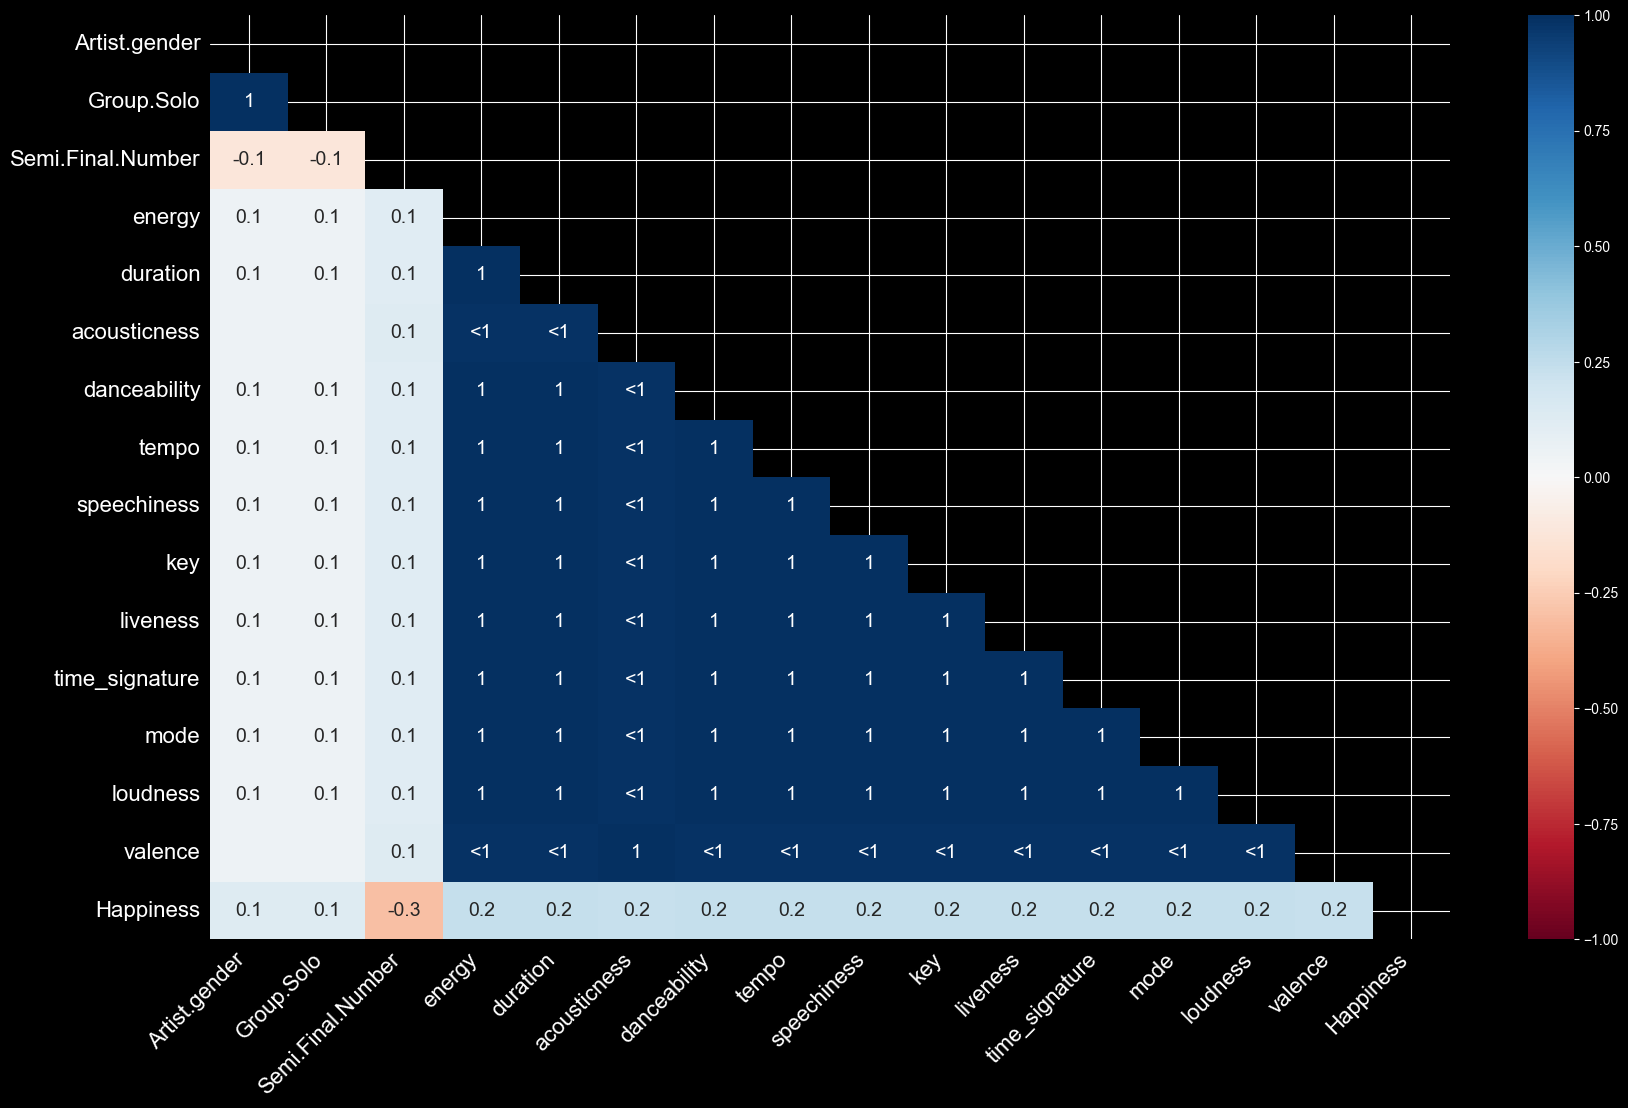

In [126]:
msno.heatmap(meta)

<Axes: >

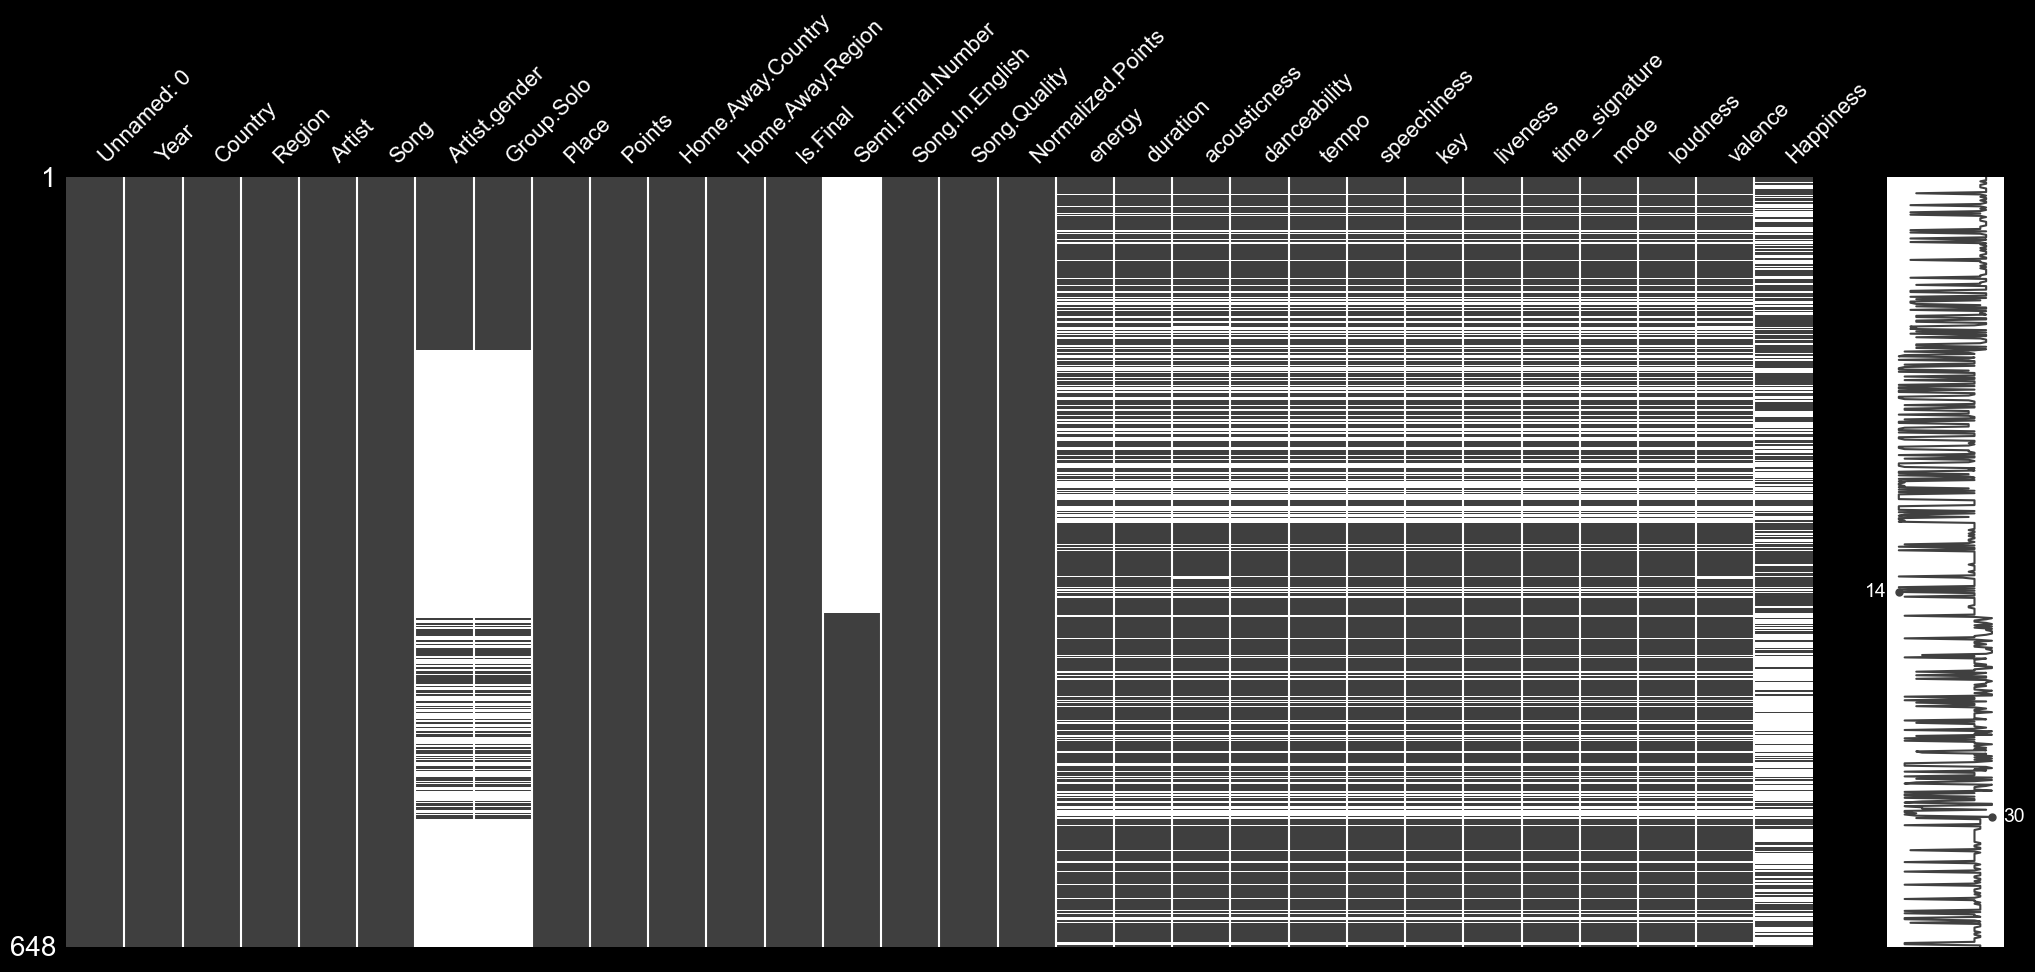

In [127]:
msno.matrix(meta)

##ZAPOZNANIE SIĘ Z DANYMI (EDA)

In [95]:
print(data.shape)
print(f"\nZbiór wyjściowy Eurovisia zawiera: {data.shape[0]} wierszy, {data.shape[1]} kolumn")
print()
print(data.head())
print(f" \nInformacje na temat typów danych:")
print()
print(data.info())
print()
  # --- Analiza braków ---
print("\n── Braki danych ──")
print()
print(data.isna().sum())
print()
#print(data1.shape)
print(f"\nZbiór wyjściowy Głosowania zawiera: {data1.shape[0]} wierszy, {data1.shape[1]} kolumn")
print()
print(data1.head())
print()



  # --- Analiza braków ---
print("\n── Braki danych ──")
print(data1.isna().sum())

#print(data1.shape)

(648, 30)

Zbiór wyjściowy Eurovisia zawiera: 648 wierszy, 30 kolumn

   Unnamed: 0  Year    Country                 Region  \
0           1  2009  Lithuania  Former Socialist Bloc   
1           2  2009     Israel            Independent   
2           3  2009     France         Western Europe   
3           4  2009     Sweden            Scandinavia   
4           5  2009    Croatia      Former Yugoslavia   

                      Artist                       Song Artist.gender  \
0                 Sasha Son                        Love          Male   
1         Noa and Mira Awad   There Must Be Another Way        Female   
2             Patricia Kaas    Et s'il fallait le faire        Female   
3             Malena Ernman                     La voix        Female   
4  Igor Cukrov feat. Andrea                 Lijepa Tena          Both   

  Group.Solo  Place  Points  ... danceability    tempo  speechiness   key  \
0       Solo     23      23  ...     0.598360  102.984     0.027817   9

In [96]:
print("\n── Braki danych ──")

braki = data.isnull().sum()

pct = (braki / len(data) * 100).round(1)

raport = pd.DataFrame({
    "braki": braki,
    "procent_%": pct
})

print(raport[raport["braki"] > 0].to_string())


── Braki danych ──
                   braki  procent_%
Artist.gender        422       65.1
Group.Solo           422       65.1
Semi.Final.Number    367       56.6
energy               166       25.6
duration             166       25.6
acousticness         168       25.9
danceability         166       25.6
tempo                166       25.6
speechiness          166       25.6
key                  166       25.6
liveness             166       25.6
time_signature       166       25.6
mode                 166       25.6
loudness             166       25.6
valence              168       25.9
Happiness            344       53.1


WNIOSKI: Trzy kolumny mają braki przekraczające 50% , natomiast 6 kolumn ma braki na poziomie ok 26%.


In [97]:
# --- Klasyfikacja braków ---
print("\n── Klasyfikacja mechanizmu braków ──")
print("Artist.gender / Group.Solo  → MAR  (brak w całych latach: 1998–2003, 2010–2012)")
print("Semi.Final.Number           → MAR  (finaliści nie mają nr półfinału — Is.Final=1)")
print("Happiness                   → MAR/MNAR? (brak dla pewnych krajów, przyczyna niejednoznaczna)")
print("energy / tempo / valence…   → MAR  (Spotify nie miało danych dla starszych piosenek)")


── Klasyfikacja mechanizmu braków ──
Artist.gender / Group.Solo  → MAR  (brak w całych latach: 1998–2003, 2010–2012)
Semi.Final.Number           → MAR  (finaliści nie mają nr półfinału — Is.Final=1)
Happiness                   → MAR/MNAR? (brak dla pewnych krajów, przyczyna niejednoznaczna)
energy / tempo / valence…   → MAR  (Spotify nie miało danych dla starszych piosenek)


Wnioski: Wszystkie powyższe braki uznajemy za MAR ponieważ w większosci przypadków zależą one od braku danych w starszych/lub konkretnych latach. Dlatego też:
-usuwamy kolumny z brakami przekraczającymi 50% i klasyfikowane jako MAR. Uznaliśmy również, że nie będa one miały wpływu na hipoteze stawianą w naszym badaniu.
INFORMACJA DLACZEGO USUWAMY RÓWNIEŻ WIERSZE Z BRAKAMI "ENERGY" W DALSZEJ CZĘŚCI OPRACOWANIA

In [98]:
print(data.columns)
# --- Czyszczenie ---
drop_cols = ["Artist.gender", "Group.Solo", "Semi.Final.Number", "Happiness"]
data = data.drop(columns=drop_cols)
data_clean = data.dropna(subset=["energy"])
print(f"\nPo czyszczeniu: {data_clean.shape[0]} wierszy, {data_clean.shape[1]} kolumn")
print(f"Usunięto: {len(data) - len(data_clean)} wierszy z brakami Spotify")

print(data.shape)
print(data_clean.shape)

Index(['Unnamed: 0', 'Year', 'Country', 'Region', 'Artist', 'Song',
       'Artist.gender', 'Group.Solo', 'Place', 'Points', 'Home.Away.Country',
       'Home.Away.Region', 'Is.Final', 'Semi.Final.Number', 'Song.In.English',
       'Song.Quality', 'Normalized.Points', 'energy', 'duration',
       'acousticness', 'danceability', 'tempo', 'speechiness', 'key',
       'liveness', 'time_signature', 'mode', 'loudness', 'valence',
       'Happiness'],
      dtype='str')

Po czyszczeniu: 482 wierszy, 26 kolumn
Usunięto: 166 wierszy z brakami Spotify
(648, 26)
(482, 26)


In [99]:
# --- Sprawdzenie reprezentatywności po czyszczeniu ---
print("\n── Reprezentatywność po usunięciu wierszy ──")
for col in ["Points", "Place"]:
    print(f"\n  {col}:")
    print(f"    Cały zbiór:    mean={data[col].mean():.1f}, std={data[col].std():.1f}")
    print(f"    Po czyszcz.:   mean={data_clean[col].mean():.1f}, std={data_clean[col].std():.1f}")
    print(f"    Różnica mean:  {data_clean[col].mean() - data[col].mean():.1f}")

    print("\n  Rozkład regionów (różnica pp):")
reg_all   = (data["Region"].value_counts(normalize=True) * 100).round(1)
reg_clean = (data_clean["Region"].value_counts(normalize=True) * 100).round(1)

for r in reg_all.index:
    diff = reg_clean.get(r, 0) - reg_all[r]
    print(f"    {r:30s}  {diff:+.1f} pp")


── Reprezentatywność po usunięciu wierszy ──

  Points:
    Cały zbiór:    mean=77.8, std=63.3
    Po czyszcz.:   mean=82.3, std=64.2
    Różnica mean:  4.5

  Rozkład regionów (różnica pp):

  Place:
    Cały zbiór:    mean=11.9, std=6.8
    Po czyszcz.:   mean=11.4, std=6.7
    Różnica mean:  -0.5

  Rozkład regionów (różnica pp):
    Former Socialist Bloc           +0.9 pp
    Western Europe                  -0.2 pp
    Scandinavia                     +2.5 pp
    Independent                     -0.6 pp
    Former Yugoslavia               -2.6 pp


W powyższym badaniu chcieliśmy sprawdzić jak zachowują się dane po usunięciu wierszy, a dokładnie jak zachowuje sie srednia i odchylenie standardowe przed i po usunięciu wierszy.

Główny wniosek: Usunięcie wierszy miało niewielki wpływ na dane. W szczególnosci miało to wpływ na średnią wszystkich punktów(Points). Różnica wynosiła 4,5, czyli o taką ilość wzrosła średnia ilość punktów po usunięciu przedmitowych wierszy.
Z kolei jeśli chodzi o zajmowane miejsce to średnia zmieniła sie nieistotnie tj.-0,5.
Natomiast jesli przedmitową zmianę odniesiemy do konkretnych Regionów wówczas: zauważamy że najwięcej zyskały na usunięciu wierszy Skandynawia i była Jugosławia.

Od teraz uzywamy danych oczyszczonych!!

In [100]:
data = data_clean.copy()

##=============================================================
 STATYSTYKI OPISOWE
===============================================================

In [119]:
data.head()

,Unnamed: 0,Year,Country,Region,Artist,Song,Place,Points,Home.Away.Country,Home.Away.Region,...,acousticness,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,23,23,Away,Home,...,0.563170,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,16,53,Away,Away,...,0.068711,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,8,107,Away,Away,...,0.654078,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,21,33,Away,Away,...,0.119194,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,18,45,Away,Away,...,0.323643,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541


In [120]:
data1.head()

,Year,Country,Giver,Score
0,2009,Lithuania,Albania,0
1,2009,Israel,Albania,0
2,2009,France,Albania,2
3,2009,Sweden,Albania,1
4,2009,Croatia,Albania,0


In [122]:
from skimpy import skim
skim(data)
skim(data1)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 482    │ │ float64     │ 14    │                                                          │
│ │ Number of columns │ 26     │ │ int64       │ 6     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 6     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column    ┃ NA ┃ NA %      ┃ mean    ┃ sd      ┃ p0        ┃ p25     ┃ p50     ┃ p75     ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ Unnamed:  │  0 │         0 │   332.7 │   192.8 │         1 │   158.5 │   351.5 │   491.8 │    648 │ ▇▅▅▇▆▇ │  │
│ │     0     │    │           │         │         │           │         │         │         │        │        │  │
│ │   Year    │  0 │         0 │    2007 │   3.657 │      1998 │    2005 │    2008 │    2010 │   2012 │ ▂▁▂▅▅▇ │  │
│ │   Place   │  0 │         0 │   11.38 │   6.727 │         1 │    5.25 │      11 │      17 │     27 │ ▇▆▆▇▃▂ │  │
│ │  Points   │  0 │         0 │   82.25 │   64.21 │         0 │      35 │      67 │     112 │    387 │  ▇▅▂▁  │  │
│ │ Is.Final  │  0 │         0 │  0.5311 │  0.4995 │         0 │       0 │       1 │       1 │      1 │ ▇    ▇ │  │
│ │ Song.In.E │  0 │         0 │  0.7656 │  0.4241 │         0 │       1 │       1 │       1 │      1 │ ▂    ▇ │  │
│ │  nglish   │    │           │         │         │           │         │         │         │        │        │  │
│ │ Song.Qual │  0 │         0 │   2.788 │   2.124 │   -0.3637 │   1.124 │   2.233 │   4.077 │  9.795 │ ▇▇▅▃▁▁ │  │
│ │    ity    │    │           │         │         │           │         │         │         │        │        │  │
│ │ Normalize │  0 │         0 │ 0.04744 │ 0.03532 │         0 │  0.0197 │ 0.03754 │ 0.06936 │ 0.1589 │ ▇▆▃▂▁▁ │  │
│ │ d.Points  │    │           │         │         │           │         │         │         │        │        │  │
│ │  energy   │  0 │         0 │  0.7258 │  0.1867 │   0.06473 │  0.6074 │    0.76 │   0.881 │ 0.9992 │  ▁▃▅▇▇ │  │
│ │ duration  │  0 │         0 │   191.3 │   34.46 │     30.02 │   179.9 │   182.2 │   185.9 │  445.8 │    ▇▁  │  │
│ │ acousticn │  2 │ 0.4149377 │  0.1643 │  0.2262 │ 0.0004133 │ 0.01451 │ 0.05746 │  0.2132 │ 0.9926 │  ▇▁▁▁  │  │
│ │    ess    │    │ 593360996 │         │         │           │         │         │         │        │        │  │
│ │ danceabil │  0 │         0 │  0.5712 │  0.1361 │    0.1837 │  0.4894 │  0.5746 │  0.6697 │ 0.8942 │ ▁▃▅▇▆▁ │  │
│ │    ity    │    │           │         │         │           │         │         │         │        │        │  │
│ │   tempo   │  0 │         0 │   113.9 │   24.96 │     64.97 │   91.97 │   121.4 │   130.2 │    212 │  ▅▃▇▁  │  │
│ │ speechine │  0 │         0 │ 0.05658 │ 0.05058 │   0.02399 │ 0.03287 │ 0.04174 │ 0.06026 │ 0.5051 │   ▇    │  │
│ │    ss     │    │           │         │         │           │         │         │         │        │        │  │
│ │    key    │  0 │         0 │   5.782 │   3.454 │    

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 12131  │ │ int64       │ 2     │                                                          │
│ │ Number of columns │ 4      │ │ string      │ 2     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃ column     ┃ NA   ┃ NA %    ┃ mean     ┃ sd       ┃ p0      ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist     ┃  │
│ ┡━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━┩  │
│ │    Year    │    0 │       0 │     2006 │     4.15 │    1998 │   2003 │   2007 │   2010 │   2012 │  ▅▃▃▇▅▇  │  │
│ │   Score    │    0 │       0 │    2.433 │    3.589 │       0 │      0 │      0 │      5 │     12 │  ▇▁▁▁▁▁  │  │
│ └────────────┴──────┴─────────┴──────────┴──────────┴─────────┴────────┴────────┴────────┴────────┴──────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃         ┃    ┃      ┃          ┃            ┃         ┃            ┃ chars per  ┃ words per   ┃ total      ┃  │
│ ┃ column  ┃ NA ┃ NA % ┃ shortest ┃ longest    ┃ min     ┃ max        ┃ row        ┃ row         ┃ words      ┃  │
│ ┡━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ Country │  0 │    0 │  Malta   │ Serbia and │ Albania │   United   │       7.59 │         1.1 │      12771 │  │
│ │         │    │      │          │ Montenegro │         │  Kingdom   │            │             │            │  │
│ │  Giver  │  0 │    0 │  Malta   │ Serbia and │ Albania │   United   │       7.64 │         1.1 │      12773 │  │
│ │         │    │      │          │ Montenegro │         │  Kingdom   │            │             │            │  │
│ └─────────┴────┴──────┴──────────┴────────────┴─────────┴────────────┴────────────┴─────────────┴────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

<Axes: >

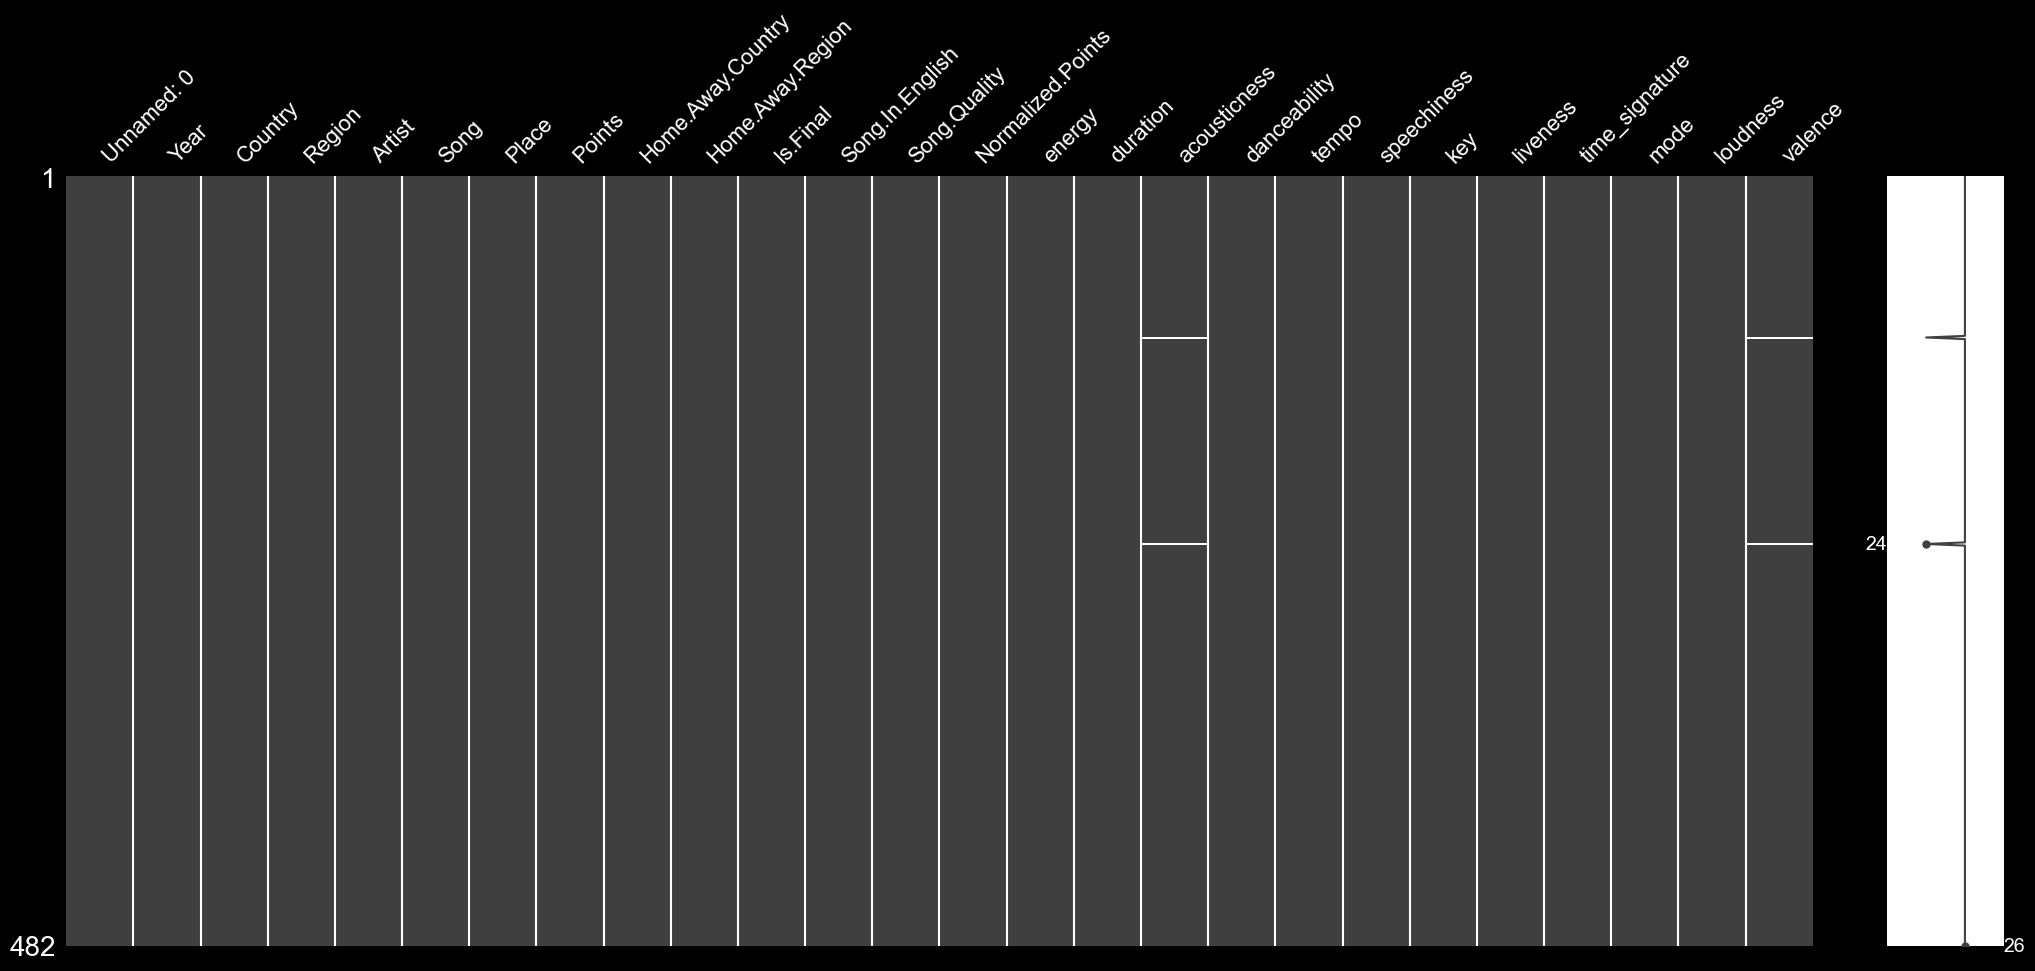

In [123]:
import missingno as msno
msno.matrix(data)

<Axes: >

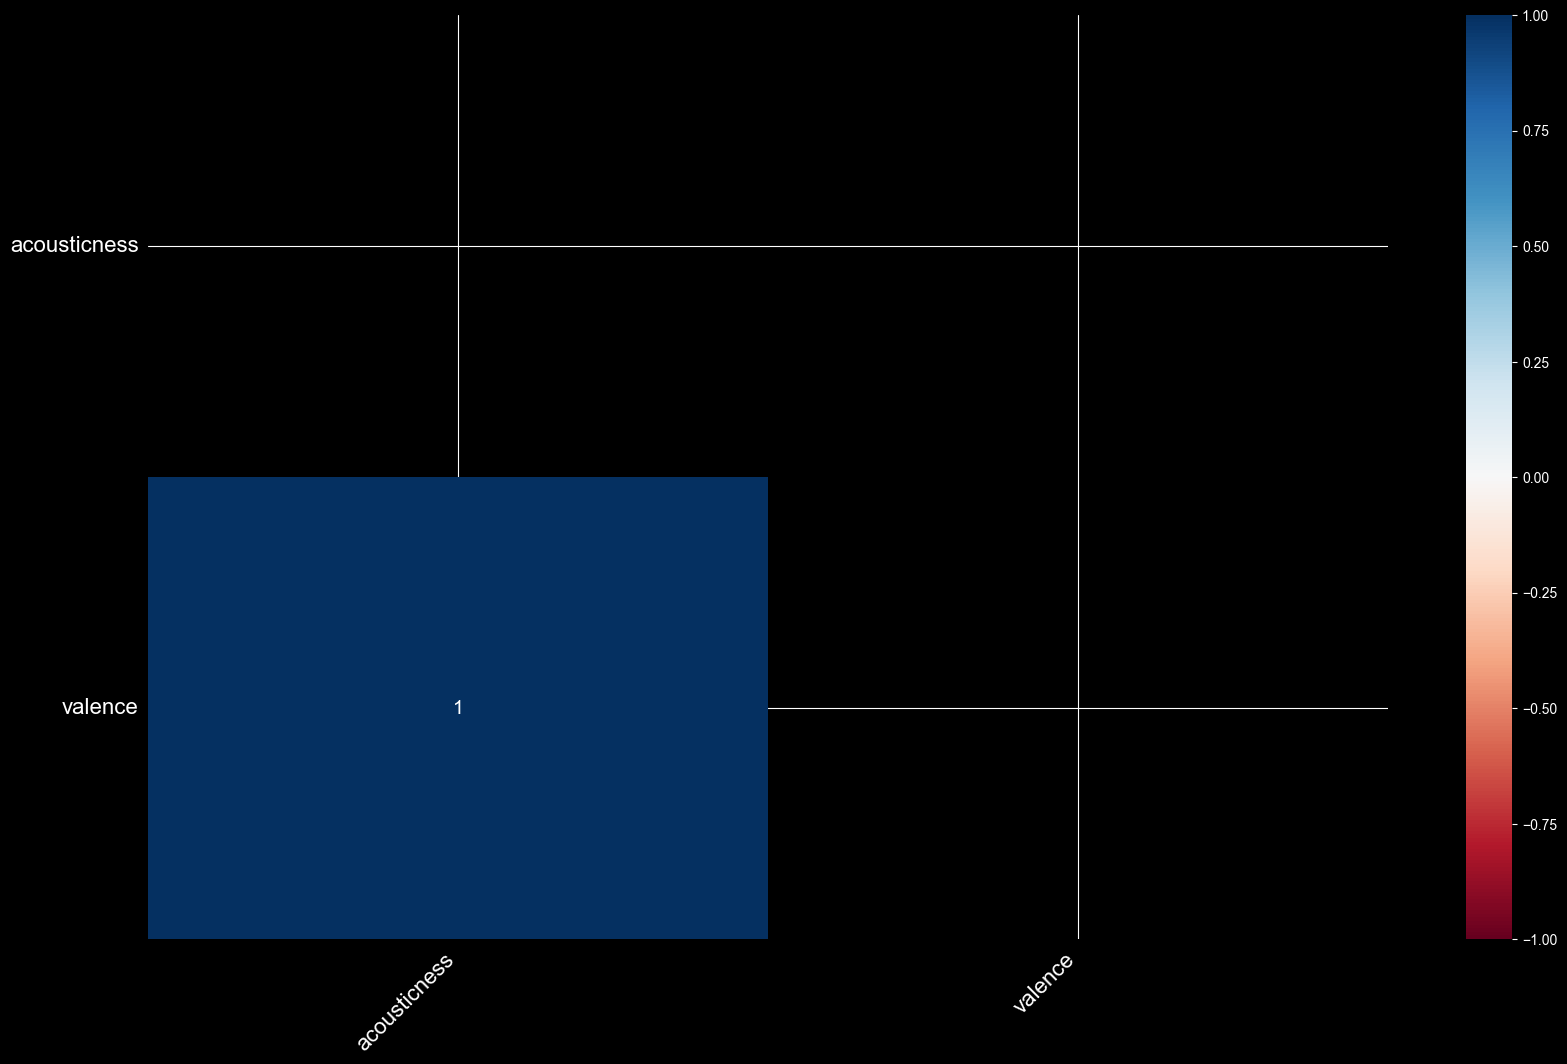

In [124]:
msno.heatmap(data)

In [101]:
# --- Skale pomiarowe ---
print("\n── Skale pomiarowe ──")
print()
skale = {
        "Country, Region":              "nominalna",
        "Is.Final, Song.In.English":    "nominalna (flaga 0/1)",
        "Place":                        "porządkowa (ranking)",
        "Year":                         "przedziałowa",
        "loudness (dB)":               "przedziałowa (0 dB ≠ cisza)",
        "Points, energy, danceability": "ilorazowa (zero abs. istnieje)",
        "tempo, valence, Song.Quality": "ilorazowa",
    }
for k, v in skale.items():
    print(f"  {k:35s} → {v}")


── Skale pomiarowe ──

  Country, Region                     → nominalna
  Is.Final, Song.In.English           → nominalna (flaga 0/1)
  Place                               → porządkowa (ranking)
  Year                                → przedziałowa
  loudness (dB)                       → przedziałowa (0 dB ≠ cisza)
  Points, energy, danceability        → ilorazowa (zero abs. istnieje)
  tempo, valence, Song.Quality        → ilorazowa


In [102]:

# --- Tendencja centralna i zmienność ---
print()
print("\n── Tendencja centralna i zmienność ──")
print()
num_cols = ["Points", "Place", "Song.Quality",
                "energy", "danceability", "tempo"]

desc = data[num_cols].agg(["mean", "median", "std", "skew"]).round(3)
desc.loc["IQR"]      = data[num_cols].apply(
    lambda x: x.quantile(0.75) - x.quantile(0.25)).round(3)
desc.loc["kurtosis"] = data[num_cols].apply(
    lambda x: stats.kurtosis(x.dropna())).round(3)
print(desc.to_string())





── Tendencja centralna i zmienność ──

          Points   Place  Song.Quality  energy  danceability    tempo
mean      82.253  11.384         2.788   0.726         0.571  113.905
median    67.000  11.000         2.233   0.760         0.575  121.358
std       64.212   6.727         2.124   0.187         0.136   24.959
skew       1.344   0.207         0.950  -0.789        -0.390    0.194
IQR       77.000  11.750         2.953   0.274         0.180   38.195
kurtosis   2.130  -0.999         0.285  -0.098        -0.150    0.272


Wnioski: Przy średniej ok 83 , medianie 67 mamy do czynienia ze skosnoscia 1.3 czyli prawostronną. Odchylenie standardowe na poziomie 64 jest tak duże jak niemalże średnia co znaczy o duzym "rozrzucie punktów", wielu dostaje niewiele a kilku dostaje bardzo dużo. Kurtoza 2,1 w porownaniu do (Gasua 0) swiadczy o długich "ogonach" czyli dużej liczbie bardzo niskich wyników co potwierdza powyzsze wnioski.

i mozna tez tak :). Zmienna Points charakteryzuje się dodatnią kurtozą (2.1), co wskazuje na większą koncentrację obserwacji wokół centrum oraz częstsze występowanie wartości skrajnych niż w rozkładzie normalnym. Oznacza to, że w zbiorze występują zarówno bardzo niskie, jak i bardzo wysokie wyniki punktowe.

In [103]:
# --- Dominanta/Moda zmiennych nominalnych ---
print("\n── Moda (nominalne) ──")
print(f"  Najczęstszy Region:  {data['Region'].mode()[0]}"
    f" ({data['Region'].value_counts().iloc[0]}x)")
print(f"  Najczęstszy Country: {data['Country'].mode()[0]}"
    f" ({data['Country'].value_counts().iloc[0]}x)")
print(f"  Piosenki po ang.:    {(data['Song.In.English']==1).sum()}"
    f" / {len(data)} ({data['Song.In.English'].mean()*100:.1f}%)")




── Moda (nominalne) ──
  Najczęstszy Region:  Former Socialist Bloc (163x)
  Najczęstszy Country: Iceland (18x)
  Piosenki po ang.:    369 / 482 (76.6%)


W analizowanym zbiorze dominują kraje "byłego bloku wschodniego". Najczęściej występującym krajem jest Islandia. Zdecydowana większość utworów (76%) wykonywana była w języku angielskim, co sugeruje silną dominację tego języka w konkursie.

In [104]:
 # --- Skośność Points ---
sk   = stats.skew(data["Points"])
kurt = stats.kurtosis(data["Points"])
print(f"\n── Rozkład Points ──")
print(f"  Skewness: {sk:.3f}"
    f"  → {'prawostronna skośność' if sk > 0 else 'lewostronna skośność'}")
print(f"  Kurtosis: {kurt:.3f}"
    f"  → {'leptokurtyczny (grube ogony)' if kurt > 0 else 'platykurtyczny'}")
print(f"  Uwaga: mediana (67) << średnia (82) — mediana jest lepszą miarą centralną")


── Rozkład Points ──
  Skewness: 1.339  → prawostronna skośność
  Kurtosis: 2.130  → leptokurtyczny (grube ogony)
  Uwaga: mediana (67) << średnia (82) — mediana jest lepszą miarą centralną


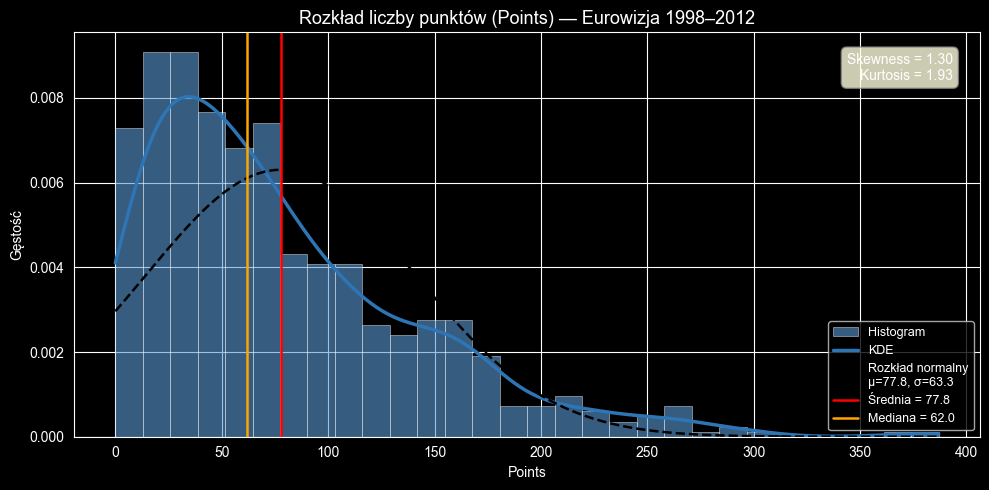

In [131]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, ax = plt.subplots(figsize=(10, 5))

# --- Histogram + KDE ---
points = data["Points"].dropna()

ax.hist(points, bins=30, density=True, color="#5B9BD5", alpha=0.6,
        edgecolor="white", linewidth=0.5, label="Histogram")

kde_x = np.linspace(points.min(), points.max(), 300)
kde = stats.gaussian_kde(points)
ax.plot(kde_x, kde(kde_x), color="#2E75B6", linewidth=2.5, label="KDE")

# --- Krzywa normalna ---
mu, s = points.mean(), points.std()
norm_y = stats.norm.pdf(kde_x, mu, s)
ax.plot(kde_x, norm_y, color="black", linewidth=1.8,
        linestyle="--", label=f"Rozkład normalny\nμ={mu:.1f}, σ={s:.1f}")

# --- Linie: średnia i mediana ---
ax.axvline(mu, color="red", linewidth=1.8, linestyle="-",
           label=f"Średnia = {mu:.1f}")
ax.axvline(points.median(), color="orange", linewidth=1.8, linestyle="-",
           label=f"Mediana = {points.median():.1f}")

# --- Adnotacje skośności i kurtozy ---
sk   = stats.skew(points)
kurt = stats.kurtosis(points)
ax.text(0.97, 0.95,
        f"Skewness = {sk:.2f}\nKurtosis = {kurt:.2f}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10, bbox=dict(boxstyle="round,pad=0.4",
        facecolor="lightyellow", edgecolor="grey", alpha=0.8))

ax.set_title("Rozkład liczby punktów (Points) — Eurowizja 1998–2012", fontsize=13)
ax.set_xlabel("Points")
ax.set_ylabel("Gęstość")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("points_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Interpretacja: potwierdzenie tego co liczyliśmy powyżej.

In [105]:
print("\n── Korelacje Pearsona z Points ──")
print()
corr_cols = [
    "Song.Quality",
    "energy",
    "danceability",
    "tempo",
    "valence",
    "loudness",
    "Normalized.Points"
]

corrs = (
    data[corr_cols + ["Points"]]
    .corr()["Points"]
    .drop("Points")
    .sort_values(ascending=False)
)

for c, r in corrs.items():
    print(f"  {c:20s}  r = {r:+.2f}")





── Korelacje Pearsona z Points ──

  Normalized.Points     r = +0.88
  Song.Quality          r = +0.87
  energy                r = +0.05
  loudness              r = +0.03
  valence               r = -0.01
  danceability          r = -0.03
  tempo                 r = -0.04


Wniosek. Cecha normalized Point ma duża korelacje ale to wynika z "przecieku" danych. Song.quality również ma duża korelację ale to wynika najprawdopodobniej ze sposobu jej stymacji. natomiast pozostałe cechy nie mają korelacji z wynikami konkursu.

##=============================================================
SAMPLING
===============================================================

In [106]:
n = len(data)
mu_hat = data["Points"].mean()
s = data["Points"].std()
se = s / np.sqrt(n)

print(f"\n── Populacja vs próba ──")
print(f"  Próba (nasz zbiór):    n = {n}  (finały i półfinały 1998–2012)")
print(f"  Populacja:             ~1200+  (cała historia Eurowizji)")
print(f"\n  x̄ (Points) = {mu_hat:.2f}")
print(f"  s          = {s:.2f}")
print(f"  SE = s/√n  = {se:.3f}")

# --- SE dla różnych n ---
print("\n── SE dla różnych n ──")
print()
for ni in [10, 30, 50, 100, 200, n]:
    label = f"n={ni}" + ("  ← nasz zbiór" if ni == n else "")
    print(f"  {label:25s}  SE = {s/np.sqrt(ni):.2f}")

# --- Symulacja rozkładu z próby (CTG) ---

print("\n── Symulacja CTG: 1000 prób, n=50 ──")
print()
np.random.seed(42)
sample_means = [data["Points"].sample(50).mean() for _ in range(1000)]
print(f"  Średnia rozkładu prób:        {np.mean(sample_means):.2f}  (≈ x̄ = {mu_hat:.2f} ✓)")
print(f"  SE empiryczny (std prób):     {np.std(sample_means):.3f}")
print(f"  SE teoretyczny (s/√50):       {s/np.sqrt(50):.3f}  ✓")




── Populacja vs próba ──
  Próba (nasz zbiór):    n = 482  (finały i półfinały 1998–2012)
  Populacja:             ~1200+  (cała historia Eurowizji)

  x̄ (Points) = 82.25
  s          = 64.21
  SE = s/√n  = 2.925

── SE dla różnych n ──

  n=10                       SE = 20.31
  n=30                       SE = 11.72
  n=50                       SE = 9.08
  n=100                      SE = 6.42
  n=200                      SE = 4.54
  n=482  ← nasz zbiór        SE = 2.92

── Symulacja CTG: 1000 prób, n=50 ──

  Średnia rozkładu prób:        82.29  (≈ x̄ = 82.25 ✓)
  SE empiryczny (std prób):     8.197
  SE teoretyczny (s/√50):       9.081  ✓


Centralne twierdzenie graniczne się potwierdziło ponieważ średnia rozkładu 1000 prpb wyniosła 82,29 czyli praktycznie tyle ile średnia 82,25 w naszym zbiorze.
Jeśli spojrzymy na bład standardowy to jest on całkiem spory tzn. 8.19 , nieznacznie różny od 9.

##=============================================================
ESTYMACJA
===============================================================

In [107]:
n = len(data)
mu_hat = data["Points"].mean()
s = data["Points"].std()
se = s / np.sqrt(n)

# --- Estymacja punktowa ---
print()
print("\n── Estymacja punktowa ──")
p_hat = data["Song.In.English"].mean()
print(f"  μ̂  (Points):           {mu_hat:.2f} pkt")
print(f"  μ̂  (Song.Quality):     {data['Song.Quality'].mean():.4f}")
print(f"  p̂  (ang. piosenki):    {p_hat:.3f}  ({p_hat*100:.1f}%)")
print(f"  σ̂  (Points):           {s:.2f} pkt")

# --- Przedziały ufności dla μ (rozkład t) ---
print("\n── Przedziały ufności dla średniej Points (t-Student, df=481) ──")
for conf in [0.90, 0.95, 0.99]:
    lo, hi = stats.t.interval(conf, df=n-1, loc=mu_hat, scale=se)
    print(f"  {int(conf*100)}% CI: [{lo:.2f}, {hi:.2f}]  (szerokość: {hi-lo:.2f} pkt)")

# --- CI dla proporcji ---
se_p = np.sqrt(p_hat * (1 - p_hat) / n)
lo_p, hi_p = stats.norm.interval(0.95, loc=p_hat, scale=se_p)
print(f"\n── 95% CI dla proporcji anglojęzycznych ──")
print(f"  p̂ = {p_hat:.3f} | SE = {se_p:.4f}")
print(f"  95% CI: [{lo_p:.3f}, {hi_p:.3f}]  czyli [{lo_p*100:.1f}%, {hi_p*100:.1f}%]")

# --- Minimalna wielkość próby ---
z95 = 1.96
n_min_mean = np.ceil((z95 * s / 5) ** 2)
n_min_prop = np.ceil((z95**2 * p_hat * (1 - p_hat)) / 0.03**2)
print(f"\n── Minimalna wielkość próby ──")
print(f"  Dokładność ±5 pkt  (95%):  n_min = {n_min_mean:.0f}  (mamy {n})")
print(f"  Dokładność ±3 pp   (95%):  n_min = {n_min_prop:.0f}")





── Estymacja punktowa ──
  μ̂  (Points):           82.25 pkt
  μ̂  (Song.Quality):     2.7885
  p̂  (ang. piosenki):    0.766  (76.6%)
  σ̂  (Points):           64.21 pkt

── Przedziały ufności dla średniej Points (t-Student, df=481) ──
  90% CI: [77.43, 87.07]  (szerokość: 9.64 pkt)
  95% CI: [76.51, 88.00]  (szerokość: 11.49 pkt)
  99% CI: [74.69, 89.82]  (szerokość: 15.13 pkt)

── 95% CI dla proporcji anglojęzycznych ──
  p̂ = 0.766 | SE = 0.0193
  95% CI: [0.728, 0.803]  czyli [72.8%, 80.3%]

── Minimalna wielkość próby ──
  Dokładność ±5 pkt  (95%):  n_min = 634  (mamy 482)
  Dokładność ±3 pp   (95%):  n_min = 767


Przedział ufnosci dal średniej liczby punktów:
Na podstawie tej próby szacujemy, że prawdziwa średnia liczba punktów w populacji mieści się w przedziale od około 76.5 do 88 pkt przy poziomie ufności 95%.
Przedział ufności dla piosenek anglojeycznych:
Szacujemy, że udział piosenek anglojęzycznych w populacji wynosi prawdopodobnie od 72.8% do 80.3%.
Po oczyszczeniu danych liczebność próby wyniosła 482 obserwacje. Jest to mniej niż wymagana liczebność dla założonej dokładności ±5 punktów dla średniej Points oraz ±3 punktów procentowych dla udziału piosenek anglojęzycznych. Oznacza to, że uzyskane przedziały ufności są szersze od zakładanych. Mimo to próba nadal pozwala na orientacyjną estymację parametrów populacji, jednak wyniki należy interpretować z większą ostrożnością.

In [108]:
# --- Estymacja wariancji (chi-kwadrat) --- Czyli sprawdzamy jaka jest wariancja populacji
s2     = data["Points"].var(ddof=1)
chi2lo = stats.chi2.ppf(0.025, df=n-1)
chi2hi = stats.chi2.ppf(0.975, df=n-1)
ci_lo  = (n-1) * s2 / chi2hi
ci_hi  = (n-1) * s2 / chi2lo
print(f"\n── Estymacja wariancji Points (rozkład χ²) ──")
print(f"  s²           = {s2:.2f}")
print(f"  95% CI dla σ²: [{ci_lo:.2f}, {ci_hi:.2f}]")
print(f"  95% CI dla σ:  [{np.sqrt(ci_lo):.2f}, {np.sqrt(ci_hi):.2f}]")


── Estymacja wariancji Points (rozkład χ²) ──
  s²           = 4123.13
  95% CI dla σ²: [3647.90, 4698.19]
  95% CI dla σ:  [60.40, 68.54]


Oszacowane odchylenie standardowe liczby punktów wynosi 64,2 pkt. Przedział ufności 95% wskazuje, że rzeczywista zmienność wyników w populacji utworów Eurowizji mieści się prawdopodobnie między 60,4 a 68,6 pkt. Oznacza to znaczną różnorodność osiąganych wyników konkursowych.

##=============================================================
TESTY STATYSTYCZNE
===============================================================

In [109]:
# --- Test 2: t-test — Final vs Semi ---
print("\n── Test 2: Finał vs Półfinał — Song.Quality ──")
fin  = data[data["Is.Final"] == 1]["Song.Quality"]
semi = data[data["Is.Final"] == 0]["Song.Quality"]
t2, p2 = stats.ttest_ind(fin, semi)
pool_s2 = np.sqrt(
    ((len(fin)-1)*fin.std()**2 + (len(semi)-1)*semi.std()**2)
    / (len(fin)+len(semi)-2))
d2 = (fin.mean() - semi.mean()) / pool_s2
print(f"  H0: μ_final = μ_semi  |  H1: μ ≠")
print(f"  Final: n={len(fin)}, x̄={fin.mean():.3f}  |  Semi: n={len(semi)}, x̄={semi.mean():.3f}")
print(f"  t={t2:.3f}, p={p2:.4f}  →  {'ODRZUCAMY H0 ✓' if p2<0.05 else 'Brak podstaw'}")






── Test 2: Finał vs Półfinał — Song.Quality ──
  H0: μ_final = μ_semi  |  H1: μ ≠
  Final: n=256, x̄=2.559  |  Semi: n=226, x̄=3.049
  t=-2.540, p=0.0114  →  ODRZUCAMY H0 ✓


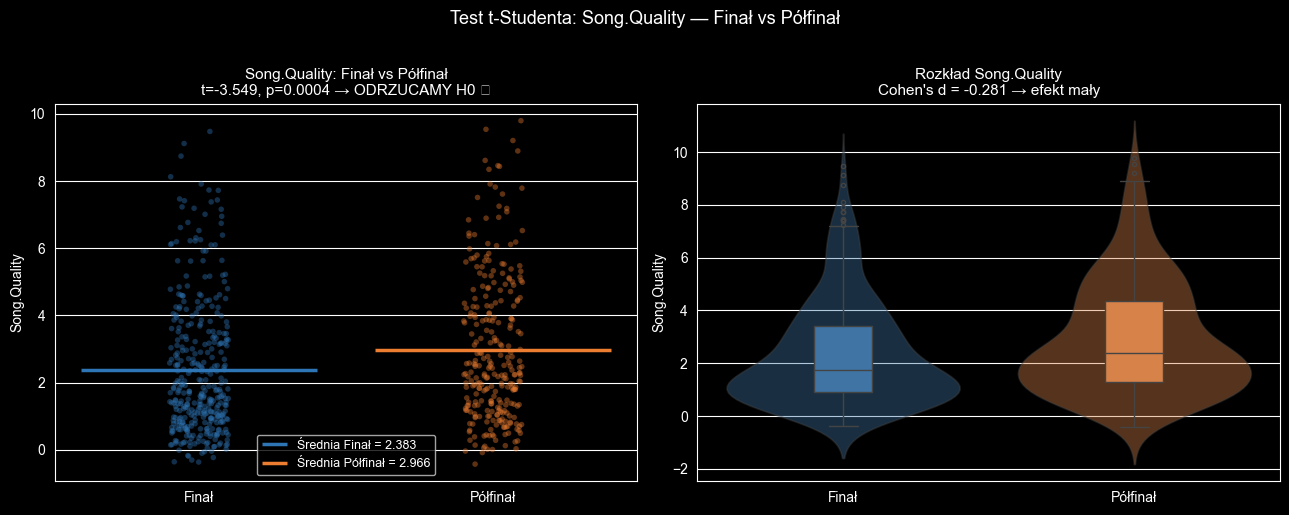

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fin  = data[data["Is.Final"] == 1]["Song.Quality"]
semi = data[data["Is.Final"] == 0]["Song.Quality"]

# --- Dane do wykresu ---
plot_data = data[["Is.Final", "Song.Quality"]].copy()
plot_data["Etap"] = plot_data["Is.Final"].map({1: "Finał", 0: "Półfinał"})

# --- Strip plot ---
ax = axes[0]
sns.stripplot(data=plot_data, x="Etap", y="Song.Quality",
              palette={"Finał": "#2E75B6", "Półfinał": "#ED7D31"},
              alpha=0.4, jitter=True, size=4, ax=ax)

# Linie średnich
for etap, kolor, val in [("Finał", "#2E75B6", fin.mean()),
                          ("Półfinał", "#ED7D31", semi.mean())]:
    ax.hlines(val, -0.4 + list(["Finał","Półfinał"]).index(etap),
              0.4 + list(["Finał","Półfinał"]).index(etap),
              colors=kolor, linewidth=2.5, label=f"Średnia {etap} = {val:.3f}")

t2, p2 = stats.ttest_ind(fin, semi)
ax.set_title(f"Song.Quality: Finał vs Półfinał\nt={t2:.3f}, p={p2:.4f} → {'ODRZUCAMY H0 ✓' if p2<0.05 else 'Brak podstaw'}",
             fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("Song.Quality")
ax.legend(fontsize=9)

# --- Boxplot + violin ---
ax2 = axes[1]
sns.violinplot(data=plot_data, x="Etap", y="Song.Quality",
               palette={"Finał": "#2E75B6", "Półfinał": "#ED7D31"},
               alpha=0.4, inner=None, ax=ax2)
sns.boxplot(data=plot_data, x="Etap", y="Song.Quality",
            palette={"Finał": "#2E75B6", "Półfinał": "#ED7D31"},
            width=0.2, fliersize=3, ax=ax2)

# Adnotacja Cohen's d
pool_s = np.sqrt(((len(fin)-1)*fin.std()**2 + (len(semi)-1)*semi.std()**2)
                 / (len(fin)+len(semi)-2))
d = (fin.mean() - semi.mean()) / pool_s
ax2.set_title(f"Rozkład Song.Quality\nCohen's d = {d:.3f} → efekt {'mały' if abs(d)<0.5 else 'średni'}",
              fontsize=11)
ax2.set_xlabel("")
ax2.set_ylabel("Song.Quality")

plt.suptitle("Test t-Studenta: Song.Quality — Finał vs Półfinał", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("ttest_songquality.png", dpi=150, bbox_inches="tight")
plt.show()

Interpretacja: Średnie ilości punktów w półfinale są wyższe niż w finale.p=0.014,0.05 czyli Istnieją statystycznie istotne dowody na różnicę średniej wartości Song.Quality pomiędzy utworami finałowymi i półfinałowymi.
d - Piosenki anglojęzyczne zdobywają więcej punktów, ale różnica jest niewielka.

In [110]:
# --- MOC Testu t-studenta ---


from statsmodels.stats.power import TTestIndPower

power = TTestIndPower().power(
    effect_size=d1,
    nobs1=len(eng),
    ratio=len(neng)/len(eng),
    alpha=0.05
)
print(f"Moc testu = {power:.3f}")

NameError: name 'd1' is not defined

Jeżeli rzeczywista różnica jest takiej wielkości jak w danych, to podobne badanie wykryje ją tylko w około 56% przypadków.Masz 44% szans ze nie wykryjesz istniejącego efektu.

In [ ]:
# --- Test 4: Spearman — Place vs energy ---
rho, p4 = stats.spearmanr(data["Place"], data["energy"])

print(f"ρ = {rho:.3f}")
print(f"p = {p4:.4f}")

if p4 < 0.05:
    print("Istnieje statystycznie istotna zależność.")
else:
    print("Brak statystycznie istotnej zależności.")





Co bada test Spearmana? Sprawdza, czy między dwiema zmiennymi istnieje zależność monotoniczna. My badalismy czy jest zaleznosc miedzy energia piosenki i miejscem. Nasza hipoteza sie nie potwierdziła.

##=============================================================
TESTY RÓŻNIC
===============================================================

In [ ]:
def _efekt_eta(eta2):
    if eta2 < 0.01: return "trywialny"
    if eta2 < 0.06: return "mały"
    if eta2 < 0.14: return "średni"
    return "duży"


regions = data["Region"].unique()

# Shapiro-Wilk
print()

print("  Shapiro-Wilk (normalność, n=30 próba):")
print()
norm_ok = True
for r in regions:
    sub    = data[data["Region"] == r]["Points"]
    sample = sub.sample(min(30, len(sub)), random_state=42)
    _, p_sw = stats.shapiro(sample)
    ok = p_sw > 0.05
    if not ok:

        norm_ok = False
        print(f"    {r:30s}  p={p_sw:.4f}  {'✓' if ok else 'rozkład nienormalny'}")

    #if not norm_ok:
     #   print()
      #  print("\n ️  Normalność naruszona ")


#sns.histplot(data, kde=True)


#plt.show()


Interpretacja: Dane w poszczególnych Regionach odbiegaja od rozkladu normalnego

In [ ]:
# --- Test A: ANOVA jednoczynnikowa ---(sprawdzimy czy srednia liczba punktów jest taka sama we wszytskich regionach)
print("\n── Test A: ANOVA jednoczynnikowa — Points ~ Region ──")
groups = [data[data["Region"] == r]["Points"].values for r in regions]

print("\n  Statystyki per region:")
for r in regions:
    sub = data[data["Region"] == r]["Points"]
    print(f"    {r:30s}  n={len(sub):3d}  x̄={sub.mean():.1f}  s={sub.std():.1f}")

F, p_anova = stats.f_oneway(*groups)
grand_mean = data["Points"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total   = sum((data["Points"] - grand_mean)**2)
eta2       = ss_between / ss_total

print(f"\n  H0: wszystkie μ równe  |  H1: co najmniej jedna para różna")
print(f"  F={F:.3f}, p={p_anova:.6f}  →  {'ODRZUCAMY H0 ✓' if p_anova<0.05 else 'Brak podstaw'}")
print(f"  Eta² = {eta2:.4f}  → region wyjaśnia {eta2*100:.1f}% wariancji  ({_efekt_eta(eta2)})")


Istnieją statystycznie istotne różnice w średniej liczbie punktów pomiędzy analizowanymi regionami Eurowizji.Region pochodzenia kraju ma związek z liczbą zdobywanych punktów.
Region tłumaczy jedynie około 3%(Eta2=2.96) różnic w liczbie zdobywanych punktów.tym samy 97% zmienności wynika z innych czynników.
Na przykład: jakości utworu, popularności wykonawcy, kolejności występu, roku konkursu,przypadku.

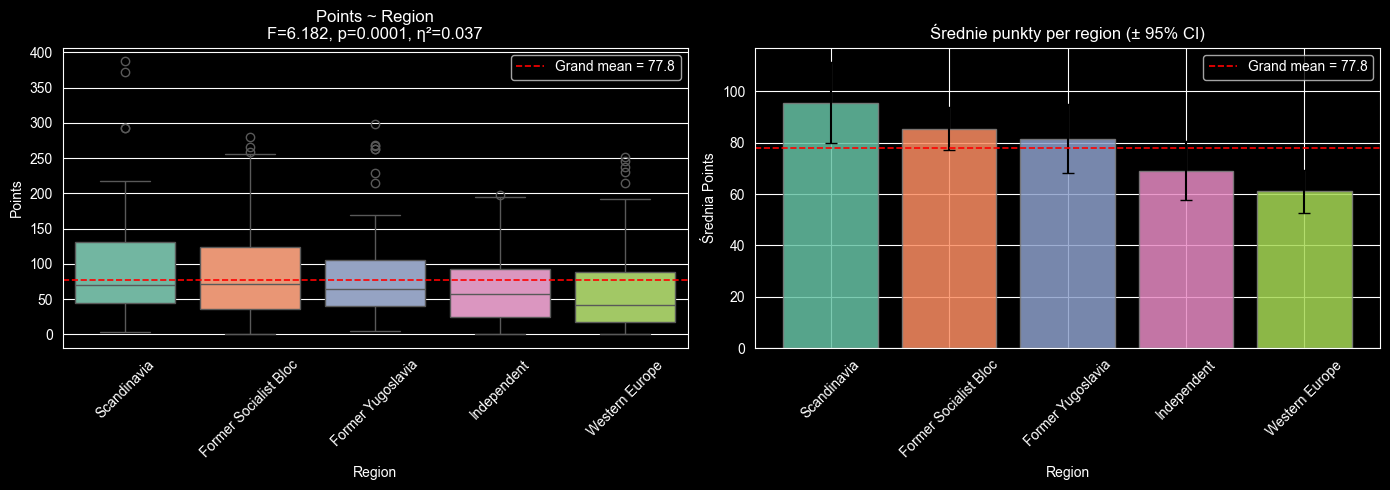

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Zmienne potrzebne do wykresu (obliczane lokalnie) ---
regions   = data["Region"].dropna().unique()
grand_mean = data["Points"].mean()
groups    = [data[data["Region"] == r]["Points"].values for r in regions]
F, p_anova = stats.f_oneway(*groups)
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total   = sum((data["Points"] - grand_mean)**2)
eta2       = ss_between / ss_total

# --- Wykres ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
ax = axes[0]
order = sorted(regions, key=lambda r: data[data["Region"]==r]["Points"].mean(), reverse=True)
sns.boxplot(data=data, x="Region", y="Points", order=order, palette="Set2", ax=ax)
ax.axhline(grand_mean, color="red", linestyle="--", linewidth=1.2, label=f"Grand mean = {grand_mean:.1f}")
ax.set_title(f"Points ~ Region\nF={F:.3f}, p={p_anova:.4f}, η²={eta2:.3f}", fontsize=12)
ax.set_xlabel("Region")
ax.set_ylabel("Points")
ax.tick_params(axis="x", rotation=45)
ax.legend()

# Barplot ze średnimi + 95% CI
ax2 = axes[1]
means = [data[data["Region"]==r]["Points"].mean() for r in order]
sems  = [data[data["Region"]==r]["Points"].sem() * 1.96 for r in order]
colors = sns.color_palette("Set2", len(order))
ax2.bar(order, means, yerr=sems, capsize=4, color=colors, edgecolor="grey", alpha=0.85)
ax2.axhline(grand_mean, color="red", linestyle="--", linewidth=1.2, label=f"Grand mean = {grand_mean:.1f}")
ax2.set_title("Średnie punkty per region (± 95% CI)", fontsize=12)
ax2.set_xlabel("Region")
ax2.set_ylabel("Średnia Points")
ax2.tick_params(axis="x", rotation=45)
ax2.legend()

plt.tight_layout()
plt.savefig("anova_region_points.png", dpi=150, bbox_inches="tight")
plt.show()

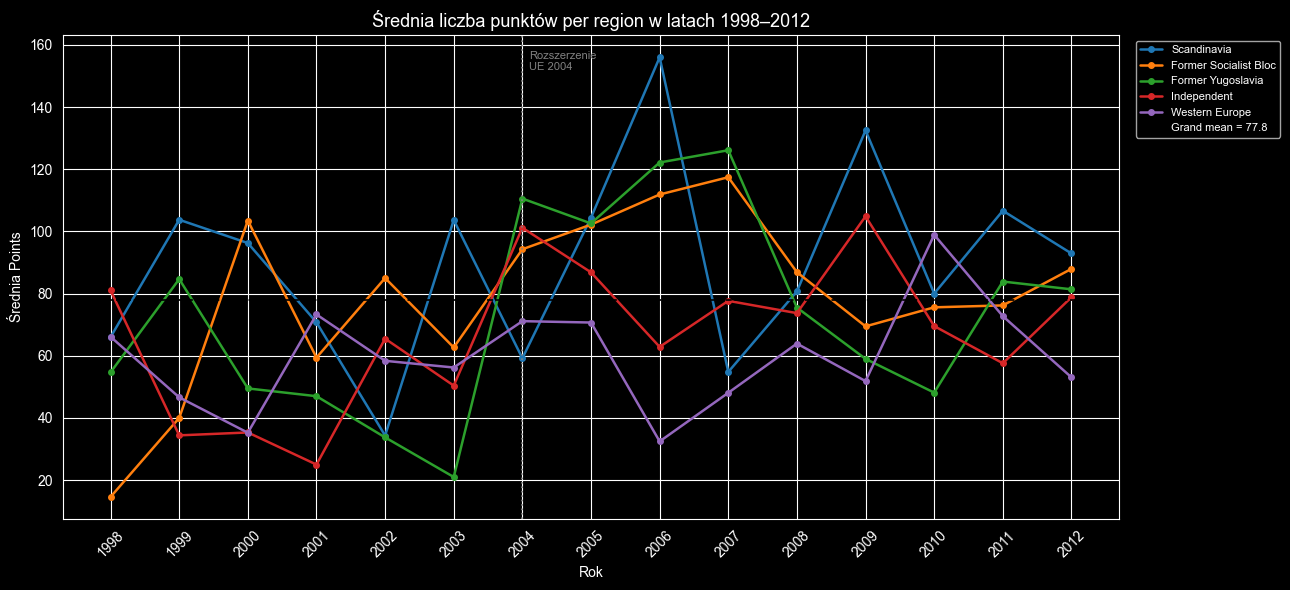

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Dane: średnia punktów per region per rok ---
trend = (data.groupby(["Year", "Region"])["Points"]
         .mean()
         .reset_index())

fig, ax = plt.subplots(figsize=(13, 6))

regions_sorted = (data.groupby("Region")["Points"]
                  .mean()
                  .sort_values(ascending=False)
                  .index.tolist())

palette = sns.color_palette("tab10", len(regions_sorted))

for i, region in enumerate(regions_sorted):
    sub = trend[trend["Region"] == region]
    ax.plot(sub["Year"], sub["Points"], marker="o", markersize=4,
            linewidth=1.8, label=region, color=palette[i])

# --- Linia grand mean ---
grand_mean = data["Points"].mean()
ax.axhline(grand_mean, color="black", linestyle="--",
           linewidth=1.2, label=f"Grand mean = {grand_mean:.1f}")

# --- 2004: rozszerzenie UE ---
ax.axvline(2004, color="grey", linestyle=":", linewidth=1.2)
ax.text(2004.1, ax.get_ylim()[1]*0.97, "Rozszerzenie\nUE 2004",
        fontsize=8, color="grey", va="top")

ax.set_title("Średnia liczba punktów per region w latach 1998–2012", fontsize=13)
ax.set_xlabel("Rok")
ax.set_ylabel("Średnia Points")
ax.set_xticks(sorted(data["Year"].unique()))
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig("trend_region_year.png", dpi=150, bbox_inches="tight")
plt.show()